<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/09_final_consolidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB09 — Consolidação Experimental e Preparação para Artigo

## 1. Contexto

Após a etapa de modelagem e comparação de modelos no NB08, este notebook realiza a consolidação final dos resultados experimentais.

O foco deixa de ser a experimentação e passa a ser a organização dos resultados de forma adequada para apresentação em artigo e dissertação.

## 2. Objetivo

Os objetivos deste notebook são:

- consolidar os resultados do modelo selecionado (baseline final);
- gerar figuras em padrão publicável;
- organizar tabelas finais de métricas;
- analisar comportamento probabilístico do modelo;
- preparar insumos diretos para o artigo.

## 3. Modelo Selecionado

Com base nos resultados do NB08, foi selecionado como modelo de referência:

- **Regressão Logística**

Justificativas:

- melhor desempenho em ROC-AUC (~0.887);
- melhor equilíbrio geral (F1 ~0.88);
- comportamento estável;
- interpretabilidade superior.

## 4. Formulação do Problema

O problema permanece definido como:

- Entrada: features da janela atual
- Saída: probabilidade de entrada em estado DURING em até 60 minutos

Trata-se de um problema de classificação binária com foco em antecipação de eventos críticos.

## 5. Estratégia Experimental

Neste notebook será utilizado:

- split temporal fixo (80/20);
- mesmas features do NB08;
- mesmo modelo (sem tuning adicional).

## 6. Saídas Esperadas

Serão geradas:

### Figuras

- Curva ROC final
- Curva Precision-Recall final
- Matriz de confusão
- Importância das features
- Probabilidade ao longo do tempo

### Tabelas

- Métricas finais
- Distribuição das classes
- Estatísticas das probabilidades

## 7. Papel no Artigo

Este notebook fornece diretamente:

- todas as figuras da seção de resultados;
- tabelas principais do artigo;
- base para discussão dos resultados.

## 8. Observações Metodológicas

- não há re-treinamento extensivo;
- não há novos modelos;
- foco exclusivo na consolidação;
- todas as decisões seguem o pipeline definido anteriormente.

## 9. Continuidade

Os artefatos gerados neste notebook serão utilizados diretamente na redação do artigo e da dissertação.

Mounted at /content/drive
FEATURES_PATH = /content/drive/MyDrive/Mestrado/02-datasets/03-features
REPORTS_PATH  = /content/drive/MyDrive/Mestrado/04-reports
MODELS_PATH   = /content/drive/MyDrive/Mestrado/03-models
Distribuição alvo: {0: 4812, 1: 1996}
Train: 5446 Test: 1362

Métricas finais:
accuracy: 0.8084
precision: 0.8234
recall: 0.9482
f1: 0.8814
roc_auc: 0.8870
average_precision: 0.9634

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.39      0.50       339
           1       0.82      0.95      0.88      1023

    accuracy                           0.81      1362
   macro avg       0.77      0.67      0.69      1362
weighted avg       0.80      0.81      0.79      1362

[NB09] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb09_final/fig_01_roc_final.png


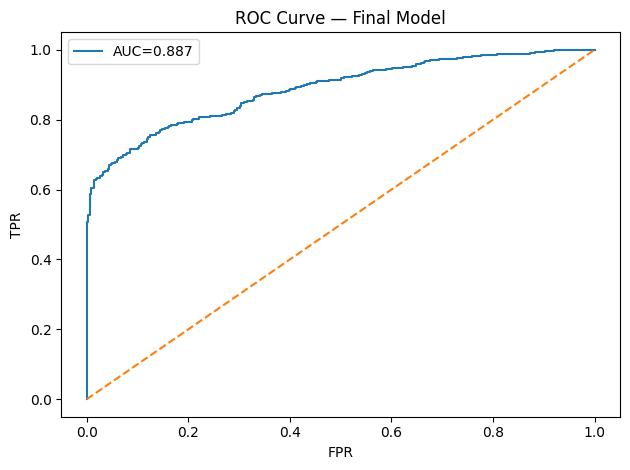

[NB09] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb09_final/fig_02_pr_final.png


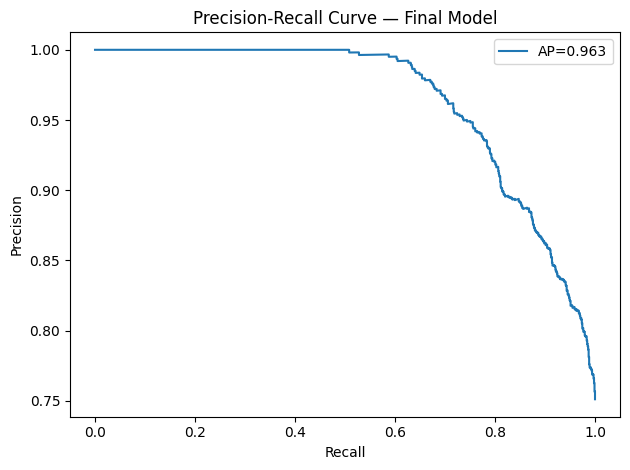

[NB09] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb09_final/fig_03_confusion_matrix.png


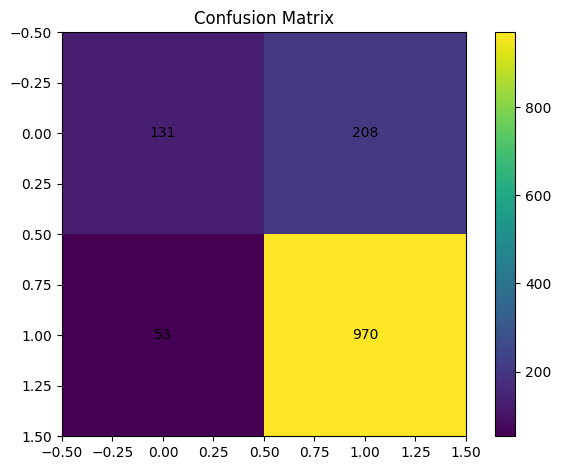

[NB09] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb09_final/fig_04_feature_importance.png


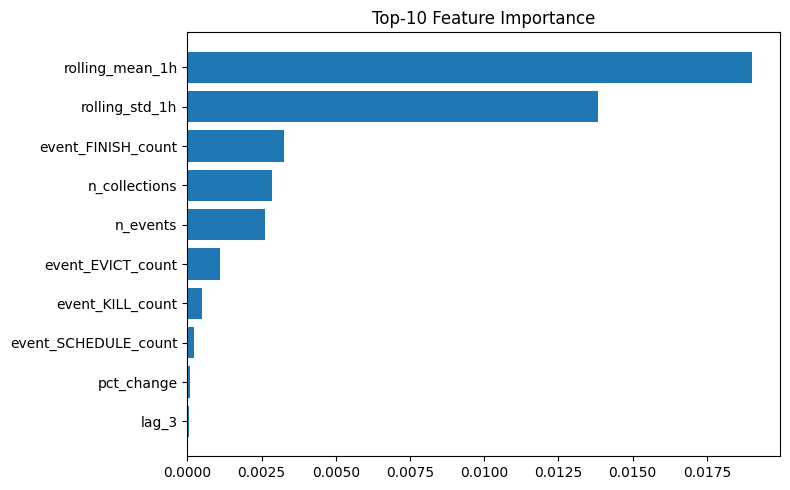

[NB09] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb09_final/fig_05_prob_time.png


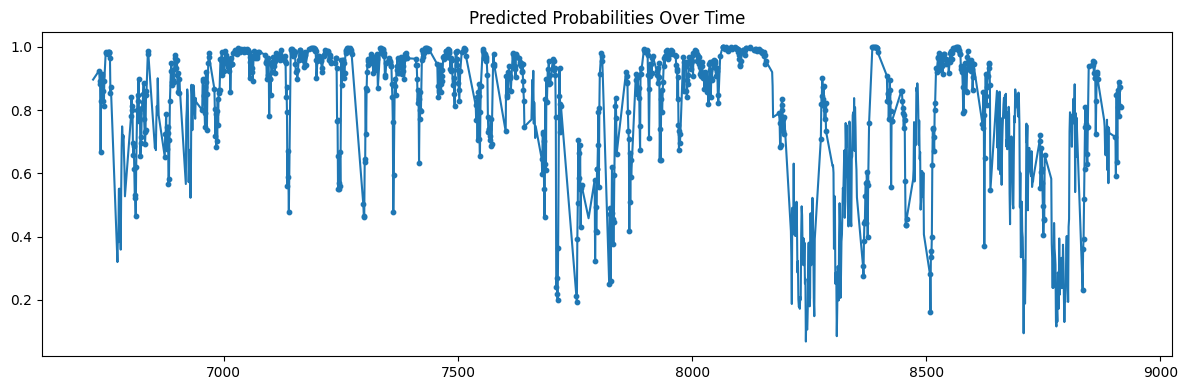


NB09 executado com sucesso.


In [1]:
# ============================================================
# 09_final_consolidation.ipynb
# Consolidação final para artigo/dissertação
# ============================================================

from pathlib import Path
import os
import sys
import subprocess
import importlib
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# BOOTSTRAP
# -----------------------------
if not Path("/content/drive/MyDrive").exists():
    from google.colab import drive
    drive.mount("/content/drive")

REPO_DIR = Path("/content/drive/MyDrive/Mestrado/PPCOMP_DM")
os.chdir(REPO_DIR)

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from src.paths import FEATURES_PATH, REPORTS_PATH, MODELS_PATH, ensure_dirs
ensure_dirs()

print("FEATURES_PATH =", FEATURES_PATH)
print("REPORTS_PATH  =", REPORTS_PATH)
print("MODELS_PATH   =", MODELS_PATH)

# -----------------------------
# IMPORTS ML
# -----------------------------
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

# -----------------------------
# INPUTS
# -----------------------------
DATA_FILE = FEATURES_PATH / "transition_dataset.parquet"
MODEL_FILE = MODELS_PATH / "logreg_transition_binary.joblib"

assert DATA_FILE.exists()
assert MODEL_FILE.exists()

FIG_DIR = REPORTS_PATH / "figures_nb09_final"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_FILE = REPORTS_PATH / "09_final_summary.json"

def save_fig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print(f"[NB09] Figura salva: {path}")

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_parquet(DATA_FILE).sort_values("bucket_id").reset_index(drop=True)

target_dist = df["transition_target"].value_counts().to_dict()
print("Distribuição alvo:", target_dist)

# -----------------------------
# FEATURES
# -----------------------------
drop_cols = {
    "bucket_id", "bucket_start_us", "next_bucket_id",
    "transition_target", "transition_label",
    "state", "next_state", "transition",
    "is_last_window", "has_valid_next",
    "future_horizon_valid", "future_has_during",
    "future_all_normal", "future_path_states",
    "future_first_during_offset",
    "prediction_horizon_minutes",
    "is_critical"
}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in numeric_cols if c not in drop_cols]

X = df[X_cols].copy()
y = df["transition_target"].astype(int)

# -----------------------------
# SPLIT TEMPORAL
# -----------------------------
n = len(df)
test_size = int(np.ceil(n * 0.2))
train_end = n - test_size

X_train = X.iloc[:train_end]
X_test  = X.iloc[train_end:]
y_train = y.iloc[:train_end]
y_test  = y.iloc[train_end:]

print("Train:", len(X_train), "Test:", len(X_test))

# -----------------------------
# LOAD MODEL
# -----------------------------
model = joblib.load(MODEL_FILE)

# -----------------------------
# PREDIÇÕES
# -----------------------------
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# -----------------------------
# MÉTRICAS
# -----------------------------
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "average_precision": average_precision_score(y_test, y_proba),
}

print("\nMétricas finais:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# ROC CURVE
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve — Final Model")
plt.legend()
save_fig("fig_01_roc_final.png")
plt.show()

# -----------------------------
# PR CURVE
# -----------------------------
prec, rec, _ = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(rec, prec, label=f"AP={metrics['average_precision']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final Model")
plt.legend()
save_fig("fig_02_pr_final.png")
plt.show()

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

save_fig("fig_03_confusion_matrix.png")
plt.show()

# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="f1"
)

pi = pd.DataFrame({
    "feature": X_cols,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(pi.head(10)["feature"][::-1], pi.head(10)["importance"][::-1])
plt.title("Top-10 Feature Importance")
save_fig("fig_04_feature_importance.png")
plt.show()

# -----------------------------
# PROBABILIDADE AO LONGO DO TEMPO
# -----------------------------
plot_df = pd.DataFrame({
    "bucket_id": df.iloc[train_end:]["bucket_id"],
    "y_true": y_test,
    "y_proba": y_proba
})

plt.figure(figsize=(12,4))
plt.plot(plot_df["bucket_id"], plot_df["y_proba"])
plt.scatter(
    plot_df[plot_df["y_true"]==1]["bucket_id"],
    plot_df[plot_df["y_true"]==1]["y_proba"],
    s=10
)
plt.title("Predicted Probabilities Over Time")
save_fig("fig_05_prob_time.png")
plt.show()

# -----------------------------
# SAVE SUMMARY
# -----------------------------
summary = {
    "metrics": metrics,
    "target_distribution": target_dist,
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "features": X_cols
}

SUMMARY_FILE.write_text(json.dumps(summary, indent=2))

print("\nNB09 executado com sucesso.")

## 8. Conclusão da Etapa

A consolidação experimental foi realizada com sucesso, confirmando a robustez do modelo selecionado e a consistência do pipeline completo.

Os resultados obtidos nesta etapa sintetizam todas as fases anteriores, demonstrando que a antecipação de eventos críticos em infraestrutura de TI é viável com alta qualidade preditiva.

---

## 9. Estrutura Final do Dataset

O dataset de transição utilizado apresenta:

- Total de amostras: **6808**
- Treino: **5446**
- Teste: **1362**

Distribuição das classes:

- Classe 0 (não entra em DURING): **4812 (~70,7%)**
- Classe 1 (entra em DURING): **1996 (~29,3%)**

Trata-se de um problema com desbalanceamento moderado, adequado para modelagem supervisionada.

---

## 10. Resultados do Modelo Final

Métricas obtidas no conjunto de teste:

- Accuracy: **0.8084**
- Precision: **0.8234**
- Recall: **0.9482**
- F1-score: **0.8814**
- ROC-AUC: **0.8870**
- Average Precision: **0.9634** :contentReference[oaicite:1]{index=1}

---

## 11. Interpretação dos Resultados

### 11.1 Capacidade de detecção de eventos

O modelo apresenta:

- Recall elevado (~0.95)
- F1-score alto (~0.88)

Interpretação:

- a maioria dos eventos críticos futuros é corretamente identificada;
- o modelo é altamente sensível a padrões pré-evento;
- o sistema apresenta forte capacidade de antecipação.

---

### 11.2 Trade-off entre classes

A matriz de confusão indica :contentReference[oaicite:2]{index=2}:

- Classe 1 (evento): excelente desempenho (970 acertos / 53 erros)
- Classe 0 (não evento): maior taxa de erro (131 acertos / 208 erros)

Interpretação:

- o modelo tende a priorizar recall da classe crítica;
- há maior incidência de falsos positivos;
- esse comportamento é coerente com aplicações de monitoramento, onde perder eventos é mais crítico que alarmes extras.

---

### 11.3 Separabilidade probabilística

As curvas ROC e Precision-Recall mostram:

- ROC-AUC ≈ **0.887**
- Average Precision ≈ **0.963** :contentReference[oaicite:3]{index=3}

Interpretação:

- excelente capacidade de ordenação das amostras;
- forte separação entre classes;
- alta confiabilidade das probabilidades previstas.

---

## 12. Importância dos Atributos

Os atributos mais relevantes identificados foram :contentReference[oaicite:4]{index=4}:

1. `rolling_mean_1h`
2. `rolling_std_1h`
3. `event_FINISH_count`
4. `n_collections`
5. `n_events`

Interpretação:

- a média e a variabilidade local da taxa são os principais preditores;
- o modelo aprende padrões dinâmicos, não apenas valores absolutos;
- a estrutura temporal local é determinante para a antecipação de eventos.

---

## 13. Dinâmica das Probabilidades

A evolução das probabilidades ao longo do tempo evidencia :contentReference[oaicite:5]{index=5}:

- regiões com probabilidade elevada próximas a eventos reais;
- transições suaves entre regimes;
- concentração de valores altos em regiões críticas.

Interpretação:

- o modelo captura a progressão do sistema rumo a estados críticos;
- há capacidade de antecipação contínua, não apenas classificação pontual;
- o comportamento é consistente com aplicações de monitoramento preditivo.

---

## 14. Interpretação Científica Integrada

Os resultados consolidados indicam que:

- a taxa de falha (`fail_rate`) é uma métrica adequada para caracterização de criticidade;
- a engenharia de atributos captura a dinâmica operacional do sistema;
- a fase pré-evento contém informação suficiente para antecipação;
- o problema apresenta estrutura estatística consistente;
- modelos simples (como regressão logística) são suficientes para capturar o fenômeno.

---

## 15. Implicações para AIOps e Monitoramento

A abordagem proposta permite:

- antecipar eventos críticos com alta sensibilidade;
- priorizar ações preventivas em sistemas distribuídos;
- reduzir impacto operacional de falhas;
- utilizar modelos interpretáveis em ambientes reais.

---

## 16. Limitações

- ausência de modelos explicitamente temporais (LSTM, Transformers);
- ausência de calibração probabilística formal;
- presença de não-estacionaridade temporal (observada no NB08);
- validação limitada a um dataset específico.

---

## 17. Conclusão Final

O Notebook 09 consolida o resultado principal da pesquisa:

- a modelagem baseada em taxa de falha permite antecipar eventos críticos;
- o pipeline completo (NB04–NB08) produz estrutura consistente e robusta;
- o problema é plenamente modelável com técnicas supervisionadas;
- há evidência clara de aplicabilidade prática.

Esses resultados sustentam diretamente a proposta do artigo e da dissertação, demonstrando a viabilidade de uso de Machine Learning para análise preditiva de estados operacionais em infraestrutura de TI.